**XGBoost Model**

In [28]:
from xgboost import XGBRegressor
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('spotify_music_cleaned.csv')
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [30]:
df = pd.get_dummies(df, columns=['track_genre'])

y = df['popularity']
X = df.drop(columns=['popularity', 'track_id', 'artists', 'track_name', 'album_name'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:20])

[51.438766 22.36053  41.340538 37.153522 37.32865  24.875208 39.42326
 31.13066  24.690826 36.02436  35.888523 21.127832 16.42712  39.069958
 42.02755  37.176758 21.3587   29.099958 38.15454  25.308815]


In [32]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

xgb_rmse = mean_squared_error(y_test, xgb_predictions) ** 0.5
xgb_r2 = r2_score(y_test, xgb_predictions)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print(xgb_rmse, xgb_r2, xgb_mae)

15.683222578889339 0.411033034324646 11.072022438049316


XGBoost Model        0.411033
Linear Regression    0.325427
Random Forest        0.469010
Name: R2, dtype: float64


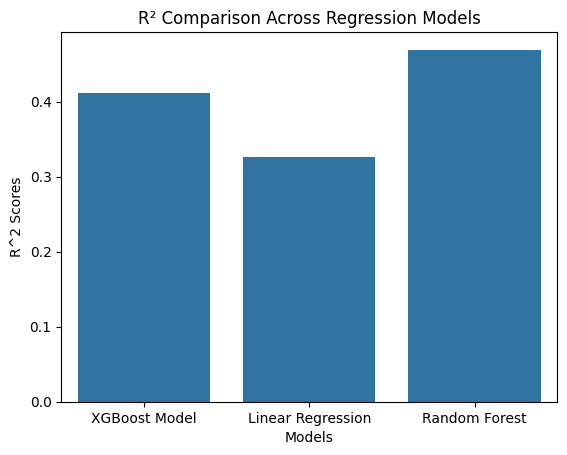

In [33]:
lr_mae, lr_r2, lr_rmse = 12.07029977294915, 0.32542737636407393, 16.90526150000689
rf_mae, rf_r2, rf_rmse = 10.116517, 0.46901, 14.998598

model_comparison = pd.DataFrame({'XGBoost Model': [xgb_rmse, xgb_r2, xgb_mae], 'Linear Regression' : [lr_rmse, lr_r2, lr_mae], 'Random Forest' : [rf_rmse, rf_r2, rf_mae]}, index = ['RMSE', 'R2', 'MAE'])
r2_comparison = model_comparison.loc['R2']
print(model_comparison.loc['R2'])


sns.barplot(x = r2_comparison.index, y = r2_comparison.values)
plt.xlabel('Models')
plt.ylabel('R^2 Scores')
plt.title('R² Comparison Across Regression Models')
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')

**Observation**

Interestingly, the xg boost model did worse than tree regressor. This may be due to the model not being fine-tuned to the data.